In [ ]:
import torch
import torch.nn as nn
import torch.nn.init as init
from torch.utils.data import Dataset, DataLoader, ConcatDataset, TensorDataset

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import axes3d
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.stats import qmc

from IPython.display import clear_output
import time
from datetime import datetime, timedelta
import gc

np.random.seed(0)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [ ]:
 # Neural Network
class PINN_Module(nn.Module):

    def __init__(self, model_parameters):
        super(PINN_Module, self).__init__()
        self.Device = model_parameters["Device"]
        self.LowerBounds = model_parameters["LowerBounds"]
        self.UpperBounds = model_parameters["UpperBounds"]
        self.InputDimensions = model_parameters["InputDimensions"]
        self.OutputDimensions = model_parameters["OutputDimensions"]
        self.NumberOfNeurons = model_parameters["NumberOfNeurons"]
        self.NumberOfHiddenLayers = model_parameters["NumberOfHiddenLayers"]
        self.ActivationFunction = model_parameters["ActivationFunction"]
        self.InputLayer = nn.Linear(self.InputDimensions, self.NumberOfNeurons)
        self.HiddenLayers = nn.ModuleList(
            [nn.Linear(self.NumberOfNeurons, self.NumberOfNeurons) for _ in range(self.NumberOfHiddenLayers - 1)])
        self.OutputLayer = nn.Linear(self.NumberOfNeurons, self.OutputDimensions)

        self.init_xavier()


    def forward(self, x):
        lb = self.LowerBounds
        ub = self.UpperBounds
        x = 2*(x - lb)/(ub - lb) - 1
        output = self.ActivationFunction(self.InputLayer(x))
        for k, l in enumerate(self.HiddenLayers):
            output = self.ActivationFunction(l(output))
        output = self.OutputLayer(output)
        return output

    def internalEnergyBalanceResidue(self, X, T):

        # Compute the derivatives of the output w.r.t. the inputs (space and time) using AD mechanism:
        diff_T = torch.autograd.grad(T, X, create_graph=True, grad_outputs=torch.ones_like(T))[0]
        Tx, Tt = diff_T[:, 0:1], diff_T[:, 1:2]

        # Compute the second derivative of the output w.r.t. the inputs (only space) using AD mechanism:
        Txx = torch.autograd.grad(Tx, X, create_graph=True, grad_outputs=torch.ones_like(T))[0][:, 0:1]

        # Compute source
        q = (-torch.sin(torch.pi*X[:, 0:1]) + torch.pi**2*torch.sin(torch.pi*X[:, 0:1]))*torch.exp(-X[:, 1:2])

        residue = Tt - Txx - q
        return residue

    def init_xavier(self):
        def init_weights(m):
            if type(m) == nn.Linear and m.weight.requires_grad and m.bias.requires_grad:
                # gain = nn.init.calculate_gain('tanh')
                gain = 1
                torch.nn.init.xavier_uniform_(m.weight, gain=gain)
                torch.nn.init.uniform_(m.bias, 0, 1)

        self.apply(init_weights)

# Problem data

In [ ]:
# Boundaries of space and time domains
ti, tf = 0.0, 1.0
xi, xf = -1.0, 1.0

lb = torch.tensor([xi, ti])
ub = torch.tensor([xf, tf])

# Initial and boundary conditions
bc_value = bc_value_l = bc_value_r = 0
u0 = lambda x: torch.sin(torch.pi*x).float()

# Exact solution

In [ ]:
# Exact solution
u_exact = lambda x, t: np.sin(np.pi*x)*np.exp(-t)

# Grid for evaluation the exact solution
x_test = np.linspace(xi, xf, 1000)
t_test = np.linspace(ti, tf, 1000)
ms_x, ms_t = np.meshgrid(x_test, t_test)
x_test = np.ravel(ms_x).reshape(-1,1)
t_test = np.ravel(ms_t).reshape(-1,1)

u_ex_grid = u_exact(x_test, t_test).reshape(ms_x.shape)

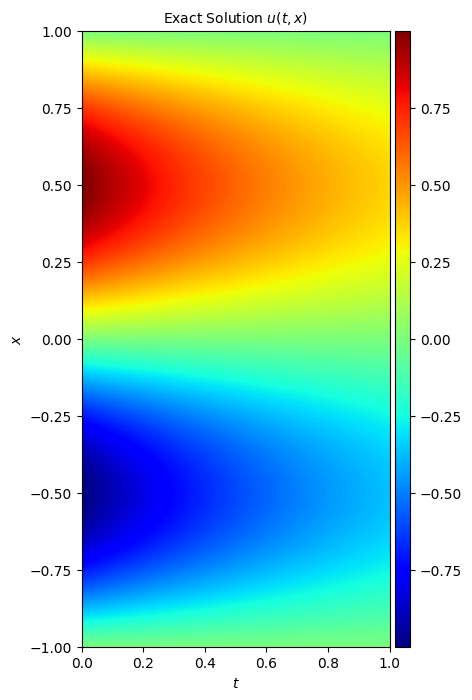

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))

h = ax.imshow(u_ex_grid.T, interpolation='nearest', cmap='jet',
              extent=[ti, tf, xi, xf],
              origin='lower', aspect='auto')
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
fig.colorbar(h, cax=cax)

ax.set_aspect('equal')
ax.set_xlabel('$t$')
ax.set_ylabel('$x$')
ax.set_title('Exact Solution $u(t,x)$', fontsize = 10)
plt.show()

# Datasets (collocation points and labelled data points)

In [ ]:
# Generate equispaced tensors for both space and time domains to pick from
x_tensor = torch.linspace(xi, xf, 10000, device=device)
t_tensor = torch.linspace(ti, tf, 10000, device=device)

# Number of collocation points
N_dom = 500 # Number of collocation points for evaluating the residuals
N_bc = 100 # Number of collocation points for computing the boundary conditions
N_ic = 200 # Number of collocation points for computing the initial condition
N_data = 1000 # Number of labelled data points

# Train, validation and testing sets
tags = ["PDE", "BoundaryConditions", "InitialCondition"]
isData = False # Flag to indicate whether the analysis would use labelled data or not

# Initialize list of dataset objects
ds = []

In [ ]:
## Collocation points for evaluating the residual of the governing PDE

# Generate collocation points within the domain using Latin Hypercube Sampling (LHS) strategy
sampler = qmc.LatinHypercube(d=2)
lhs_np = sampler.random(n=N_dom)
lhs_torch = torch.tensor(lhs_np, dtype=torch.float32)
X_dom = (lb.cpu() + (ub.cpu() - lb.cpu())*lhs_torch).to(torch.float32)
y_dom = torch.zeros((N_dom, 1), device=device)

ds.append(TensorDataset(X_dom, y_dom))

In [ ]:
## Collocation points for evaluating the boundary and initial conditions

# Generate random collocation points for the left boundary
idx_bc = np.random.choice(t_tensor.size()[0], N_bc, replace=False)
t_bc_l = t_tensor[idx_bc].view(-1, 1)
x_bc_l = xi*torch.ones((N_bc, 1), device=device)
X_bc_l = torch.cat([x_bc_l, t_bc_l], axis=1)
y_bc_l = torch.full((N_bc, 1), bc_value_l, device=device)

# Generate random collocation points for the right boundary
idx_bc = np.random.choice(t_tensor.size()[0], N_bc, replace=False)
t_bc_r = t_tensor[idx_bc].view(-1, 1)
x_bc_r = xf*torch.ones((N_bc, 1), device=device)
X_bc_r = torch.cat([x_bc_r, t_bc_r], axis=1)
y_bc_r = torch.full((N_bc, 1), bc_value_r, device=device)

# Concatenate the collocation points of both boundaries
X_bc = torch.cat([X_bc_l, X_bc_r], axis=0)
y_bc = torch.cat([y_bc_l, y_bc_r], axis=0)
ds.append(TensorDataset(X_bc, y_bc))

# Generate collocation points for the initial condition
idx_ic = np.random.choice(x_tensor.size()[0], N_ic, replace=False)
x_ic = x_tensor[idx_ic].view(-1, 1)
t_ic = ti*torch.ones((N_ic, 1), device=device)
X_ic = torch.cat([x_ic, t_ic], axis=1)
y_ic = u0(x_ic).float()
ds.append(TensorDataset(X_ic, y_ic))

In [ ]:
# Generate syntetic temperature labelled data
if isData:
    tags.append("LabelledData")
    idx_data = np.random.choice(x_tensor.size()[0], N_data, replace=False)
    omega = 0.01
    sensor_loc = 0.5
    x_data = torch.full((N_data, 1), sensor_loc, device=device)
    t_data = t_tensor[idx_data].view(-1, 1)
    X_data = torch.cat([x_data, t_data], axis=1)
    exact_temp_data = u_exact(x_data.data.cpu().numpy(), t_data.data.cpu().numpy())
    noisy_temp_data = exact_temp_data + omega*np.max(exact_temp_data)*np.random.normal(size=(N_data, 1))
    y_data = torch.from_numpy(noisy_temp_data).to(torch.float32).to(device)
    ds.append(TensorDataset(X_data, y_data))


In [ ]:
# Dictionary of dataset objects
datasets = dict(zip(tags, ds))

In [ ]:
# Plot the locations of the collocation points in the space-time domain
def plotDatasets(datasets, strategy=None, X_dom_train=None, add_samples=None):

    if X_dom_train==None:
        X_dom_train = (datasets["PDE"][:][0]).data.cpu().numpy()
    else:
        X_dom_train = X_dom_train.data.cpu().numpy()
    X_bc_train = (datasets["BoundaryConditions"][:][0]).data.cpu().numpy()
    X_ic_train = (datasets["InitialCondition"][:][0]).data.cpu().numpy()
    fig = plt.figure()
    ax = fig.add_subplot(111)

    if strategy=='RAR-G' or strategy=='RAR-D':
        lenX = len(X_dom_train)
        ax.scatter(X_dom_train[:lenX-add_samples, 1:2], X_dom_train[:lenX-add_samples, 0:1], s=4, c='r', label=f'N_dom={lenX-add_samples-1}')
        ax.scatter(X_dom_train[lenX-add_samples:, 1:2], X_dom_train[lenX-add_samples:, 0:1], s=16, c='k', marker='x', label=f'N_dom_add={add_samples}')

    elif strategy=='RAD':
        ax.scatter(X_dom_train[:, 1:2], X_dom_train[:, 0:1], s=4, c='r', label=f'N_dom={len(X_dom_train)}')

    else:
        ax.scatter(X_dom_train[:, 1:2], X_dom_train[:, 0:1], s=4, c='r', label=f'N_dom={len(X_dom_train)}')

    ax.scatter(X_bc_train[:, 1:2], X_bc_train[:, 0:1], s=4, c='b', label=f'N_bc={len(X_bc_train)}')
    ax.scatter(X_ic_train[:, 1:2], X_ic_train[:, 0:1], s=4, c='g', label=f'N_ic={len(X_ic_train)}')
    if "LabelledData" in datasets:
        X_data_train = (datasets["LabelledData"][:][0]).data.cpu().numpy()
        y_data_train = (datasets["LabelledData"][:][1]).data.cpu().numpy()
        ax.scatter(X_data_train[:, 1:2], X_data_train[:, 0:1], s=4, c='m', label=f'N_Data={len(X_data_train)}', marker='x')
    ax.legend()
    plt.xlabel('Time domain (t)')
    plt.ylabel('Space domain (x)')
    plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left")
    plt.show()

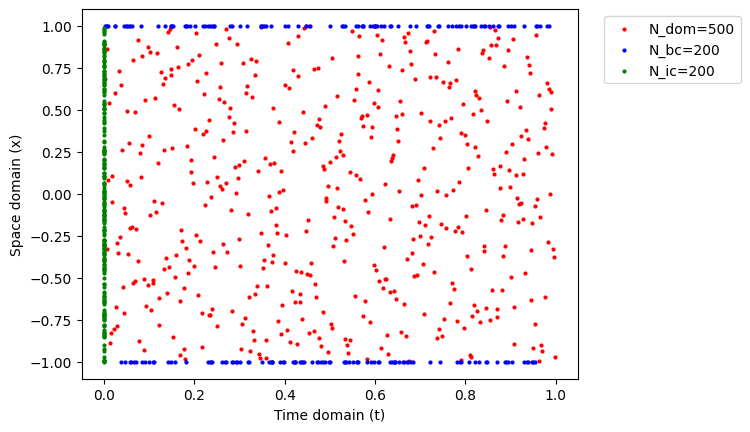

In [ ]:
plotDatasets(datasets)

In [ ]:
if isData:
    fig = plt.figure()
    X_data_train = (datasets["LabelledData"].X).data.cpu().numpy()
    y_data_train = (datasets["LabelledData"].y).data.cpu().numpy()
    ax = fig.add_subplot(111)
    t_data = np.linspace(ti, tf, 1000).reshape(-1, 1)
    T_ex = u_exact(np.full((1000, 1), sensor_loc), t_data)
    ax.plot(t_data, T_ex, c='k', label='T. exact')
    ax.scatter(X_data_train[:, 1:2], y_data_train, s=4, c='m', label='T. noisy')
    ax.legend()
    plt.xlabel('Time domain (t)')
    plt.ylabel('Temperature (T)')
    plt.title(f'Temperature at sensor location (x_s={sensor_loc})')
    plt.show()

# Initialization

In [ ]:
# Input dictionary for model instance
model_parameters = {
    "Device": device,
    "LowerBounds": lb.to(device),
    "UpperBounds": ub.to(device),
    "InputDimensions": 2,
    "OutputDimensions": 1,
    "NumberOfNeurons": 20,
    "NumberOfHiddenLayers": 4,
    "ActivationFunction": nn.Tanh()
}

# Main execution under RAR-G strategy

## Train loop

In [ ]:
# Model construction
torch.manual_seed(10)
model = PINN_Module(model_parameters).to(device)

In [ ]:
# Fitting stage using RAR-G strategy
t0 = datetime.now()
data_time_now = datetime.now().strftime("%d%m%Y_%H%M%S")

epochs = 15000
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
loss_train = []
loss_train_dom = []
loss_train_bc = []
loss_train_ic = []
loss_train_data = []
train_keys = ['Overall', 'PDE', 'BC', 'IC', 'Data']
X_pde = (datasets['PDE'][:][0]).to(device)
add_samples = 0
for epoch in range(epochs):
    loss_list = []
    optimizer.zero_grad()
    for tag in tags:
        if tag=='PDE':
            if epoch % 100 == 0 and epoch!=0:
                X = (lb + (ub - lb)*torch.rand(10_000, 2)).to(device)  #S_0
                X.requires_grad = True
                T = model(X)
                y_hat = torch.abs(model.internalEnergyBalanceResidue(X, T))
                idx = torch.topk(y_hat.flatten(), 1, dim=0)[1]
                X_pde = torch.cat([X_pde.detach(), X[idx, :].detach()], axis=0)
                add_samples += 1

            X_pde.requires_grad = True
            T = model(X_pde)
            y_hat = model.internalEnergyBalanceResidue(X_pde, T)
            loss = loss_fn(y_hat, torch.zeros_like(y_hat))
            loss_list.append(loss)

        else:
            X = (datasets[tag][:][0]).to(device)
            y = (datasets[tag][:][1]).float().to(device)
            T = model(X)
            loss = loss_fn(T, y)
            loss_list.append(loss)

    loss = sum(loss_list)
    loss.backward()
    optimizer.step()

    loss_list.insert(0, loss)
    loss_train.append(loss_list[0].item())
    loss_train_dom.append(loss_list[1].item())
    loss_train_bc.append(loss_list[2].item())
    loss_train_ic.append(loss_list[3].item())
    if isData:
        loss_train_data.append(loss_list[4].item())

    if epoch % 100 == 0:
        log_dict = dict(zip(train_keys, loss_list))
        aux = "".join(f"{key}: {value:.5e}, " for key, value in log_dict.items())
        optimizer_str = type(optimizer).__name__
        print(f"##TRAIN## {optimizer_str} - Epoch: {epoch}, " + aux)

elapsed_time_train = datetime.now() - t0
print("\nTraining Time: ", elapsed_time_train.seconds, "[s]")

##TRAIN## Adam - Epoch: 0, Overall: 1.96535e+01, PDE: 1.71491e+01, BC: 1.06322e+00, IC: 1.44112e+00, 
##TRAIN## Adam - Epoch: 100, Overall: 1.75429e+01, PDE: 1.69360e+01, BC: 1.16129e-01, IC: 4.90785e-01, 
##TRAIN## Adam - Epoch: 200, Overall: 1.63134e+01, PDE: 1.58743e+01, BC: 8.76154e-02, IC: 3.51472e-01, 
##TRAIN## Adam - Epoch: 300, Overall: 1.38352e+01, PDE: 1.32873e+01, BC: 3.06706e-01, IC: 2.41194e-01, 
##TRAIN## Adam - Epoch: 400, Overall: 8.78932e+00, PDE: 8.00341e+00, BC: 6.43154e-01, IC: 1.42759e-01, 
##TRAIN## Adam - Epoch: 500, Overall: 4.60633e+00, PDE: 3.85107e+00, BC: 6.72876e-01, IC: 8.23852e-02, 
##TRAIN## Adam - Epoch: 600, Overall: 3.38349e+00, PDE: 2.82921e+00, BC: 4.83539e-01, IC: 7.07453e-02, 
##TRAIN## Adam - Epoch: 700, Overall: 2.45367e+00, PDE: 2.06639e+00, BC: 3.12588e-01, IC: 7.46974e-02, 
##TRAIN## Adam - Epoch: 800, Overall: 1.68234e+00, PDE: 1.39859e+00, BC: 2.08421e-01, IC: 7.53319e-02, 
##TRAIN## Adam - Epoch: 900, Overall: 1.15674e+00, PDE: 9.36536e-0

## Loss functions

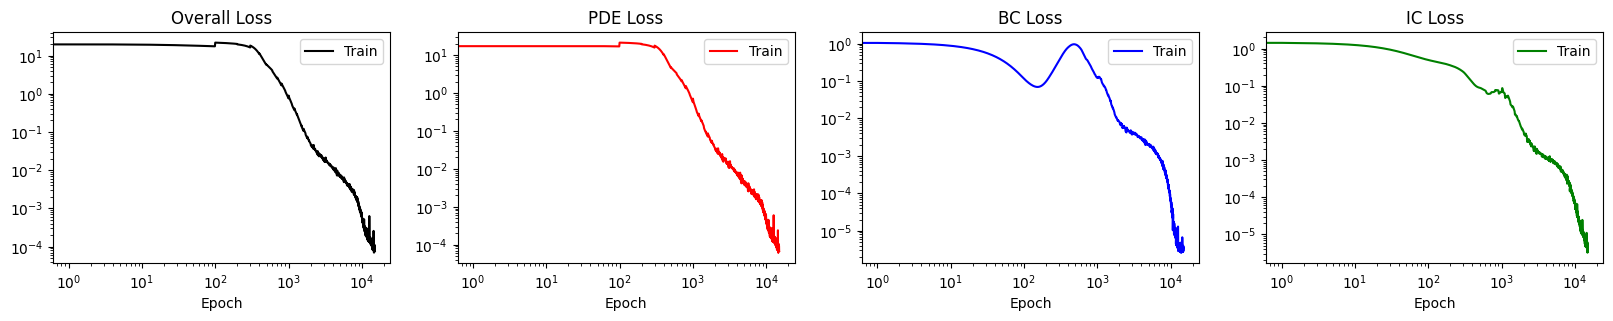

In [ ]:
# Evolution of the loss function
loss_train_list = [loss_train, loss_train_dom, loss_train_bc, loss_train_ic]
colors = ['black', 'red', 'blue', 'green']
titles = ['Overall Loss', 'PDE Loss', 'BC Loss', 'IC Loss']
if isData:
    loss_train_list.append(loss_train_data)
    colors.append('magenta')
    titles.append('Data Loss')

fig, ax = plt.subplots(1, len(loss_train_list), figsize=(20, 3))
for i in range(len(loss_train_list)):
    epochs_train = np.arange(0, len(loss_train_list[i]))
    ax[i].loglog(epochs_train, loss_train_list[i], color=colors[i], label='Train')
    ax[i].set_xlabel('Epoch')
    ax[i].set_title(titles[i])
    ax[i].legend()
plt.show()

## Final dataset

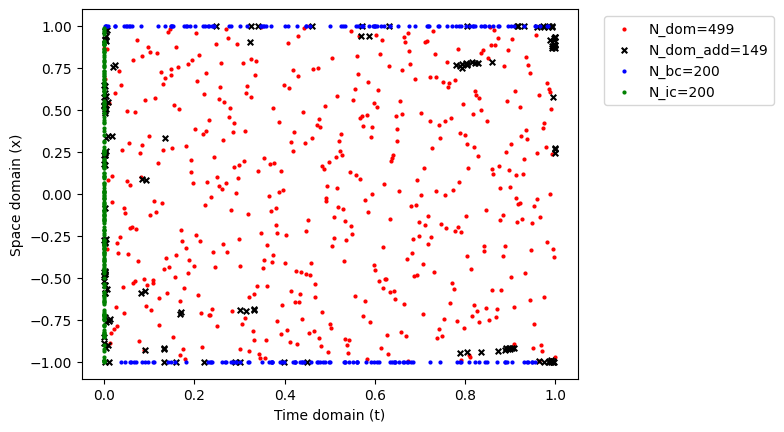

In [ ]:
plotDatasets(datasets, 'RAR-G', X_pde, add_samples)

## Prediction

In [ ]:
# Definition of tensors from the testing points for evaluating the trained PINN
pt_x = torch.from_numpy(x_test).float()
pt_t = torch.from_numpy(t_test).float()
ms_Tex = u_exact(x_test, t_test).reshape(ms_x.shape)

In [ ]:
# Predicted solution
X_pred = torch.cat([pt_x, pt_t], axis=1).to(device)
Tpred = model(X_pred).data.cpu().numpy()
ms_Tpred = Tpred.reshape(ms_x.shape)

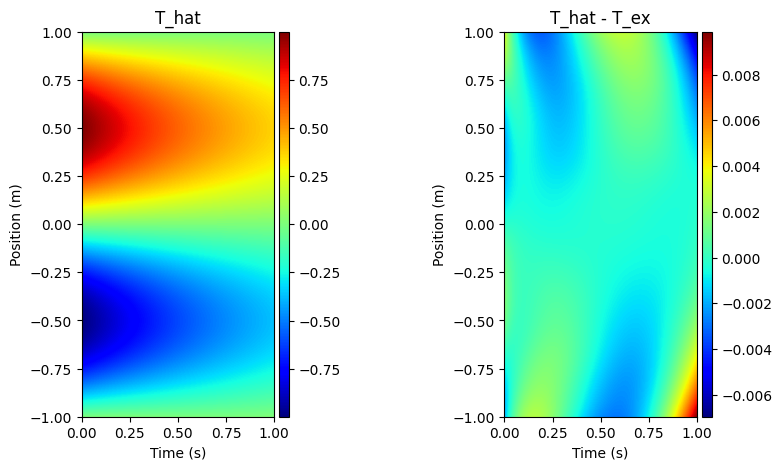

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

ax = axs[0]
h = ax.imshow(ms_Tpred.T, interpolation='nearest', cmap='jet',
              extent=[ti, tf, xi, xf],
              origin='lower', aspect='auto')
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
fig.colorbar(h, cax=cax, shrink=0.5, aspect=10)
ax.set_aspect('equal')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Position (m)')
ax.set_title('T_hat')

ax = axs[1]
h = ax.imshow((ms_Tpred-ms_Tex).T, interpolation='nearest', cmap='jet',
              extent=[ti, tf, xi, xf],
              origin='lower', aspect='auto')
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
fig.colorbar(h, cax=cax, shrink=0.5, aspect=10)
ax.set_aspect('equal')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Position (m)')
ax.set_title('T_hat - T_ex')

plt.show()

# Main execution under RAD strategy

## Train loop

In [ ]:
# Model construction
torch.manual_seed(10)
model = PINN_Module(model_parameters).to(device)

In [ ]:
# Fitting stage using RAD strategy

t0 = datetime.now()
data_time_now = datetime.now().strftime("%d%m%Y_%H%M%S")

epochs = 15000
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
loss_train = []
loss_train_dom = []
loss_train_bc = []
loss_train_ic = []
loss_train_data = []
train_keys = ['Overall', 'PDE', 'BC', 'IC', 'Data']
X_pde = (datasets['PDE'][:][0]).to(device)

# Hyperparameters of RAD
k = 1; c = 1
add_samples = 0

for epoch in range(epochs):
    loss_list = []
    optimizer.zero_grad()
    for tag in tags:
        if tag=='PDE':
            if epoch % 100 == 0 and epoch!=0:
                X = (lb + (ub - lb)*torch.rand(10000, 2)).to(device)
                X.requires_grad = True
                T = model(X)
                y_hat = torch.abs(model.internalEnergyBalanceResidue(X, T))
                err_eq = torch.pow(y_hat, k)/torch.pow(y_hat, k).mean() + c
                err_eq_normalized = (err_eq/sum(err_eq))[:, 0]
                idx = np.random.choice(a=len(X), size=N_dom, replace=False, p=err_eq_normalized.data.detach().cpu().numpy())
                X_pde = X[idx.flatten(), :].detach()
                add_samples += 1

            X_pde.requires_grad = True
            T = model(X_pde)
            y_hat = model.internalEnergyBalanceResidue(X_pde, T)
            loss = loss_fn(y_hat, torch.zeros_like(y_hat))
            loss_list.append(loss)

        else:
            X = (datasets[tag][:][0]).to(device)
            y = (datasets[tag][:][1]).float().to(device)
            T = model(X)
            loss = loss_fn(T, y)
            loss_list.append(loss)

    loss = sum(loss_list)
    loss.backward()
    optimizer.step()

    loss_list.insert(0, loss)
    loss_train.append(loss_list[0].item())
    loss_train_dom.append(loss_list[1].item())
    loss_train_bc.append(loss_list[2].item())
    loss_train_ic.append(loss_list[3].item())
    if isData:
        loss_train_data.append(loss_list[4].item())

    if epoch % 100 == 0:
        log_dict = dict(zip(train_keys, loss_list))
        aux = "".join(f"{key}: {value:.5e}, " for key, value in log_dict.items())
        optimizer_str = type(optimizer).__name__
        print(f"##TRAIN## {optimizer_str} - Epoch: {epoch}, " + aux)

elapsed_time_train = datetime.now() - t0
print("\nTraining Time: ", elapsed_time_train.seconds, "[s]")

##TRAIN## Adam - Epoch: 0, Overall: 1.96535e+01, PDE: 1.71491e+01, BC: 1.06322e+00, IC: 1.44112e+00, 
##TRAIN## Adam - Epoch: 100, Overall: 2.17588e+01, PDE: 2.11519e+01, BC: 1.16129e-01, IC: 4.90785e-01, 
##TRAIN## Adam - Epoch: 200, Overall: 1.95785e+01, PDE: 1.91287e+01, BC: 9.70006e-02, IC: 3.52737e-01, 
##TRAIN## Adam - Epoch: 300, Overall: 1.81938e+01, PDE: 1.76084e+01, BC: 3.49920e-01, IC: 2.35529e-01, 
##TRAIN## Adam - Epoch: 400, Overall: 1.13406e+01, PDE: 1.04231e+01, BC: 7.94168e-01, IC: 1.23265e-01, 
##TRAIN## Adam - Epoch: 500, Overall: 5.80619e+00, PDE: 4.76458e+00, BC: 9.53751e-01, IC: 8.78598e-02, 
##TRAIN## Adam - Epoch: 600, Overall: 3.89378e+00, PDE: 3.10586e+00, BC: 7.13291e-01, IC: 7.46282e-02, 
##TRAIN## Adam - Epoch: 700, Overall: 2.64826e+00, PDE: 2.19600e+00, BC: 3.91634e-01, IC: 6.06285e-02, 
##TRAIN## Adam - Epoch: 800, Overall: 1.85610e+00, PDE: 1.52589e+00, BC: 2.61736e-01, IC: 6.84803e-02, 
##TRAIN## Adam - Epoch: 900, Overall: 1.17073e+00, PDE: 9.24547e-0

## Loss functions

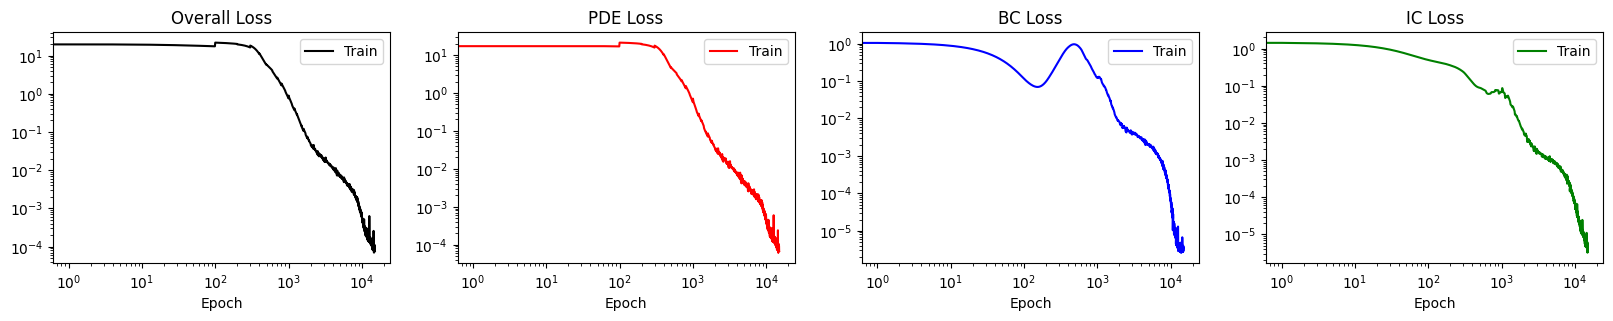

In [ ]:
# Evolution of the loss function
loss_train_list = [loss_train, loss_train_dom, loss_train_bc, loss_train_ic]
colors = ['black', 'red', 'blue', 'green']
titles = ['Overall Loss', 'PDE Loss', 'BC Loss', 'IC Loss']
if isData:
    loss_train_list.append(loss_train_data)
    colors.append('magenta')
    titles.append('Data Loss')

fig, ax = plt.subplots(1, len(loss_train_list), figsize=(20, 3))
for i in range(len(loss_train_list)):
    epochs_train = np.arange(0, len(loss_train_list[i]))
    ax[i].loglog(epochs_train, loss_train_list[i], color=colors[i], label='Train')
    ax[i].set_xlabel('Epoch')
    ax[i].set_title(titles[i])
    ax[i].legend()
plt.show()

## Final dataset

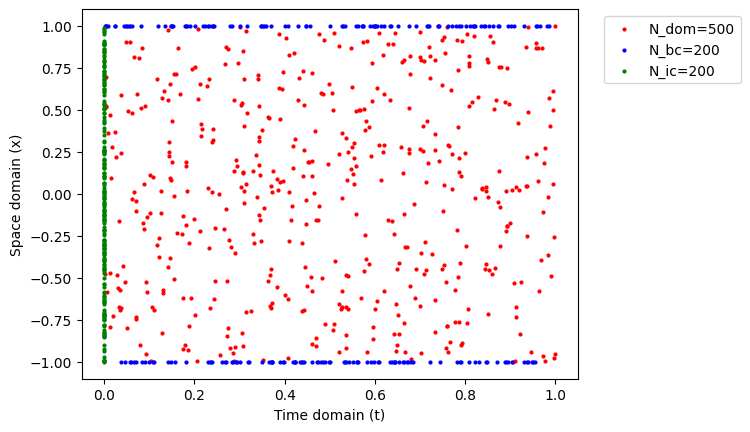

In [ ]:
plotDatasets(datasets, 'RAD', X_pde)

## Prediction

In [ ]:
# Definition of tensors from the testing points for evaluating the trained PINN
pt_x = torch.from_numpy(x_test).float()
pt_t = torch.from_numpy(t_test).float()
ms_Tex = u_exact(x_test, t_test).reshape(ms_x.shape)

In [ ]:
# Predicted solution
X_pred = torch.cat([pt_x, pt_t], axis=1).to(device)
Tpred = model(X_pred).data.cpu().numpy()
ms_Tpred = Tpred.reshape(ms_x.shape)

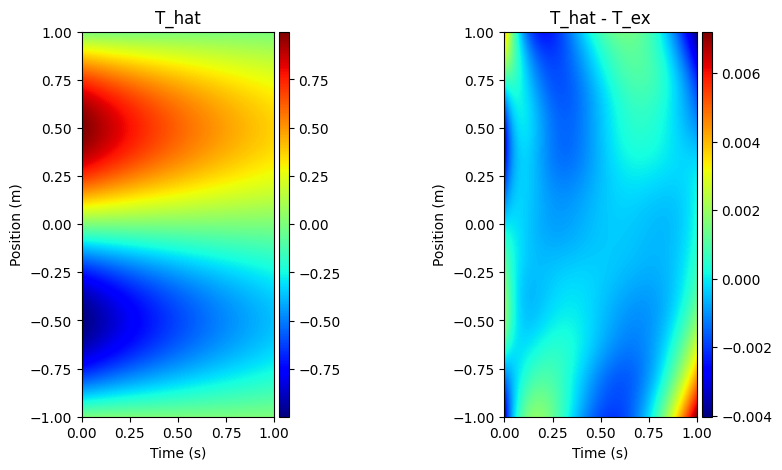

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

ax = axs[0]
h = ax.imshow(ms_Tpred.T, interpolation='nearest', cmap='jet',
              extent=[ti, tf, xi, xf],
              origin='lower', aspect='auto')
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
fig.colorbar(h, cax=cax, shrink=0.5, aspect=10)
ax.set_aspect('equal')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Position (m)')
ax.set_title('T_hat')

ax = axs[1]
h = ax.imshow((ms_Tpred-ms_Tex).T, interpolation='nearest', cmap='jet',
              extent=[ti, tf, xi, xf],
              origin='lower', aspect='auto')
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
fig.colorbar(h, cax=cax, shrink=0.5, aspect=10)
ax.set_aspect('equal')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Position (m)')
ax.set_title('T_hat - T_ex')

plt.show()

# Main execution under RAR-D strategy

## Train loop

In [ ]:
# Model construction
torch.manual_seed(10)
model = PINN_Module(model_parameters).to(device)

In [ ]:
# Fitting stage using RAR-D strategy

t0 = datetime.now()
data_time_now = datetime.now().strftime("%d%m%Y_%H%M%S")

epochs = 15000
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
loss_train = []
loss_train_dom = []
loss_train_bc = []
loss_train_ic = []
loss_train_data = []
train_keys = ['Overall', 'PDE', 'BC', 'IC', 'Data']
X_pde = (datasets['PDE'][:][0]).to(device)

# Hyperparameters of RAR-D
k = 2; c = 0
add_samples = 0

for epoch in range(epochs):
    loss_list = []
    optimizer.zero_grad()
    for tag in tags:
        if tag=='PDE':
            if epoch % 100 == 0 and epoch!=0:
                X = (lb + (ub - lb)*torch.rand(10000, 2)).to(device)
                X.requires_grad = True
                T = model(X)
                y_hat = torch.abs(model.internalEnergyBalanceResidue(X, T))
                err_eq = torch.pow(y_hat, k)/torch.pow(y_hat, k).mean() + c
                err_eq_normalized = (err_eq/sum(err_eq))[:, 0]
                idx = np.random.choice(a=len(X), size=1, replace=False, p=err_eq_normalized.data.detach().cpu().numpy())
                X_pde = torch.cat([X_pde.detach(), X[idx.flatten(), :].detach()], axis=0)
                add_samples += 1

            X_pde.requires_grad = True
            T = model(X_pde)
            y_hat = model.internalEnergyBalanceResidue(X_pde, T)
            loss = loss_fn(y_hat, torch.zeros_like(y_hat))
            loss_list.append(loss)

        else:
            X = (datasets[tag][:][0]).to(device)
            y = (datasets[tag][:][1]).float().to(device)
            T = model(X)
            loss = loss_fn(T, y)
            loss_list.append(loss)

    loss = sum(loss_list)
    loss.backward()
    optimizer.step()

    loss_list.insert(0, loss)
    loss_train.append(loss_list[0].item())
    loss_train_dom.append(loss_list[1].item())
    loss_train_bc.append(loss_list[2].item())
    loss_train_ic.append(loss_list[3].item())
    if isData:
        loss_train_data.append(loss_list[4].item())

    if epoch % 100 == 0:
        log_dict = dict(zip(train_keys, loss_list))
        aux = "".join(f"{key}: {value:.5e}, " for key, value in log_dict.items())
        optimizer_str = type(optimizer).__name__
        print(f"##TRAIN## {optimizer_str} - Epoch: {epoch}, " + aux)

elapsed_time_train = datetime.now() - t0
print("\nTraining Time: ", elapsed_time_train.seconds, "[s]")

##TRAIN## Adam - Epoch: 0, Overall: 1.96535e+01, PDE: 1.71491e+01, BC: 1.06322e+00, IC: 1.44112e+00, 
##TRAIN## Adam - Epoch: 100, Overall: 1.73974e+01, PDE: 1.67905e+01, BC: 1.16129e-01, IC: 4.90785e-01, 
##TRAIN## Adam - Epoch: 200, Overall: 1.61335e+01, PDE: 1.56940e+01, BC: 8.74264e-02, IC: 3.52097e-01, 
##TRAIN## Adam - Epoch: 300, Overall: 1.36037e+01, PDE: 1.30569e+01, BC: 3.04798e-01, IC: 2.42048e-01, 
##TRAIN## Adam - Epoch: 400, Overall: 8.52093e+00, PDE: 7.73833e+00, BC: 6.38799e-01, IC: 1.43801e-01, 
##TRAIN## Adam - Epoch: 500, Overall: 4.36002e+00, PDE: 3.61938e+00, BC: 6.57282e-01, IC: 8.33572e-02, 
##TRAIN## Adam - Epoch: 600, Overall: 3.15591e+00, PDE: 2.62007e+00, BC: 4.64504e-01, IC: 7.13391e-02, 
##TRAIN## Adam - Epoch: 700, Overall: 2.26636e+00, PDE: 1.89011e+00, BC: 2.99978e-01, IC: 7.62687e-02, 
##TRAIN## Adam - Epoch: 800, Overall: 1.54218e+00, PDE: 1.26234e+00, BC: 2.01980e-01, IC: 7.78664e-02, 
##TRAIN## Adam - Epoch: 900, Overall: 1.06985e+00, PDE: 8.52038e-0

## Loss functions

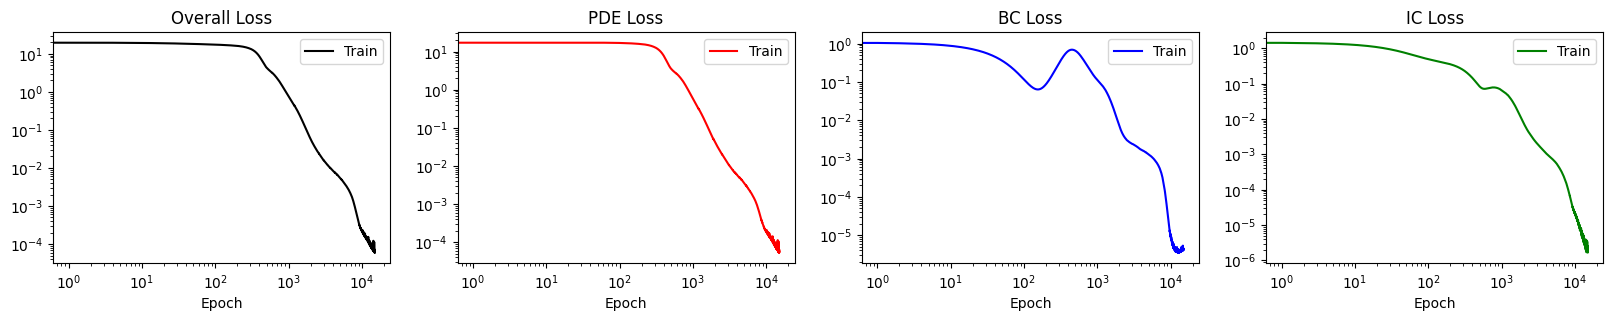

In [ ]:
# Evolution of the loss function
loss_train_list = [loss_train, loss_train_dom, loss_train_bc, loss_train_ic]
colors = ['black', 'red', 'blue', 'green']
titles = ['Overall Loss', 'PDE Loss', 'BC Loss', 'IC Loss']
if isData:
    loss_train_list.append(loss_train_data)
    colors.append('magenta')
    titles.append('Data Loss')

fig, ax = plt.subplots(1, len(loss_train_list), figsize=(20, 3))
for i in range(len(loss_train_list)):
    epochs_train = np.arange(0, len(loss_train_list[i]))
    ax[i].loglog(epochs_train, loss_train_list[i], color=colors[i], label='Train')
    ax[i].set_xlabel('Epoch')
    ax[i].set_title(titles[i])
    ax[i].legend()
plt.show()

## Final dataset

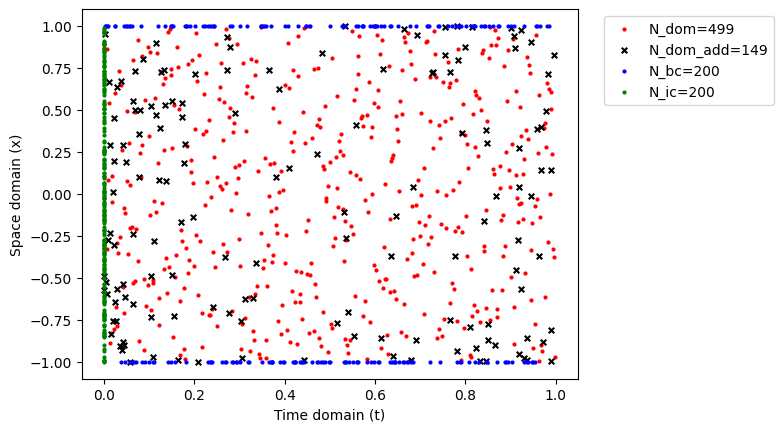

In [ ]:
plotDatasets(datasets, 'RAR-D', X_pde, add_samples)

## Prediction

In [ ]:
# Definition of tensors from the testing points for evaluating the trained PINN
pt_x = torch.from_numpy(x_test).float()
pt_t = torch.from_numpy(t_test).float()
ms_Tex = u_exact(x_test, t_test).reshape(ms_x.shape)

In [ ]:
# Predicted solution
X_pred = torch.cat([pt_x, pt_t], axis=1).to(device)
Tpred = model(X_pred).data.cpu().numpy()
ms_Tpred = Tpred.reshape(ms_x.shape)

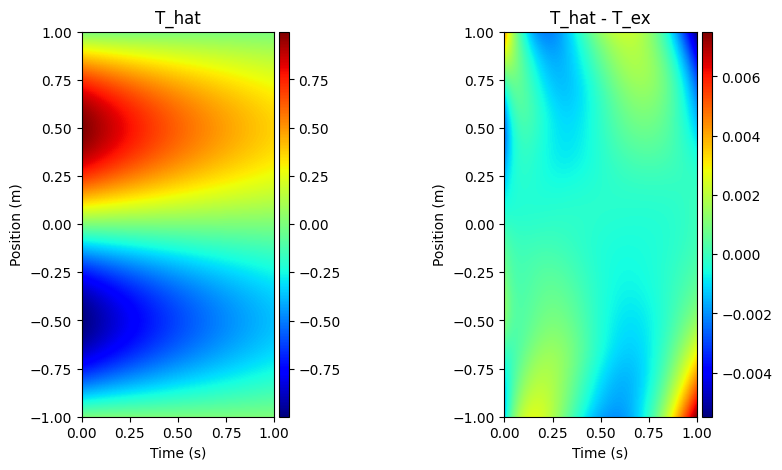

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

ax = axs[0]
h = ax.imshow(ms_Tpred.T, interpolation='nearest', cmap='jet',
              extent=[ti, tf, xi, xf],
              origin='lower', aspect='auto')
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
fig.colorbar(h, cax=cax, shrink=0.5, aspect=10)
ax.set_aspect('equal')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Position (m)')
ax.set_title('T_hat')

ax = axs[1]
h = ax.imshow((ms_Tpred-ms_Tex).T, interpolation='nearest', cmap='jet',
              extent=[ti, tf, xi, xf],
              origin='lower', aspect='auto')
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
fig.colorbar(h, cax=cax, shrink=0.5, aspect=10)
ax.set_aspect('equal')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Position (m)')
ax.set_title('T_hat - T_ex')

plt.show()